# Responsible AI: XAI GenAI project

## 0. Background



Based on the previous lessons on explainability, post-hoc methods are used to explain the model, such as saliency map, SmoothGrad, LRP, LIME, and SHAP. Take LRP (Layer Wise Relevance Propagation) as an example; it highlights the most relevant pixels to obtain a prediction of the class "cat" by backpropagating the relevance. (image source: [Montavon et. al (2016)](https://giorgiomorales.github.io/Layer-wise-Relevance-Propagation-in-Pytorch/))

<!-- %%[markdown] -->
![LRP example](images/catLRP.jpg)

Another example is about text sentiment classification, here we show a case of visualizing the importance of words given the prediction of 'positive':

![text example](images/textGradL2.png)

where the words highlight with darker colours indicate to be more critical in predicting the sentence to be 'positive' in sentiment.
More examples could be found [here](http://34.160.227.66/?models=sst2-tiny&dataset=sst_dev&hidden_modules=Explanations_Attention&layout=default).

Both cases above require the class or the prediction of the model. But:

***How do you explain a model that does not predict but generates?***

In this project, we will work on explaining the generative model based on the dependency between words. We will first look at a simple example, and using Point-wise Mutual Information (PMI) to compute the saliency map of the sentence. After that we will contruct the expereiment step by step, followed by exercises and questions.


## 1. A simple example to start with
Given a sample sentence: 
> *Tokyo is the capital city of Japan.* 

We are going to explain this sentence by finding the dependency using a saliency map between words.
The dependency of two words in the sentence could be measured by [Point-wise mutual information (PMI)](https://en.wikipedia.org/wiki/Pointwise_mutual_information): 


Mask two words out, e.g. 
> \[MASK-1\] is the captial city of \[MASK-2\].


Ask the generative model to fill in the sentence 10 times, and we have:

| MASK-1      | MASK-2 |
| ----------- | ----------- |
|    tokyo   |     japan   |
|  paris  |     france    |
|  london  |     england    |
|  paris  |     france    |
|  beijing |  china |
|    tokyo   |     japan   |
|  paris  |     france    |
|  paris  |     france    |
|  london  |     england    |
|  beijing |  china |

PMI is calculated by: 

$PMI(x,y)=log_2⁡ \frac{p(\{x,y\}| s-\{x,y\})}{P(\{x\}|s-\{x,y\})P(\{y\}|s-\{x,y\})}$

where $x$, $y$ represents the words that we masked out, $s$ represents the sentence, and $s-\{x,y\}$ represents the sentences tokens after removing the words $x$ and $y$.

In this example we have $PMI(Tokyo, Japan) = log_2 \frac{0.2}{0.2 * 0.2} = 2.32$

Select an interesting word in the sentences; we can now compute the PMI between all other words and the chosen word using the generative model:
(Here, we use a longer sentence and run 20 responses per word.)
![](images/resPMI.png)


## 2. Preparation
### 2.1 Conda enviroment

```
conda env create -f environment.yml
conda activate xai_llm
```


### 2.2 Download the offline LLM

We use the offline LLM model from hugging face. It's approximately 5 GB.
Download it using the comman below, and save it under `./models/`.
```
huggingface-cli download TheBloke/openchat-3.5-0106-GGUF openchat-3.5-0106.Q4_K_M.gguf --local-dir . --local-dir-use-symlinks False
# credit to https://huggingface.co/TheBloke/openchat-3.5-0106-GGUF
```
Command with new package version:

In [1]:
#! hf download TheBloke/openchat-3.5-0106-GGUF openchat-3.5-0106.Q4_K_M.gguf --local-dir ./models

## 3. Mask the sentence and get the responses from LLM
### 3.1 Get the input sentence

**Remember to change the anchor word index when changing the input sentence.**

In [1]:
def get_input():
    # ideally this reads inputs from a file, now it just takes an input
    return input("Enter a sentence: ")
 
#sentence = get_input()
sentence = "Soccer is a popular sport worldwide"
print("Sentence: ", sentence)

Sentence:  Soccer is a popular sport worldwide


### 3.2 Load the model

In [2]:
from models.ChatModel import ChatModel
model_name = "openchat"
model = ChatModel(model_name)
print(f"Model: {model_name}")

llama_context: n_ctx_per_seq (150) < n_ctx_train (8192) -- the full capacity of the model will not be utilized


Model: openchat


### 3.3 Run the prompts and get all the responses


In [3]:
from tools.command_generator import generate_prompts, prefix_prompt
from tools.evaluate_response import get_replacements
from tqdm import tqdm

def run_prompts(model, sentence, anchor_idx=0, prompts_per_word=20):
    prompts = generate_prompts(sentence, anchor_idx)
    all_replacements = []
    for prompt in prompts:
        replacements = []
        for _ in tqdm(
            range(prompts_per_word),
            desc=f"Input: {prompt}",
        ):
            response = model.get_response(
                prefix_prompt(prompt),
            ).strip()
            if response:
                replacement = get_replacements(prompt, response)
                if replacement:
                    replacements.append(replacement)
        if len(replacements) > 0:
            all_replacements.append(replacements)
    return all_replacements

anchor_word_idx = 4 # the index of the interested word
prompts_per_word = 20 # number of generated responses  
all_responses = run_prompts(model, sentence, anchor_word_idx, prompts_per_word)

Input: [MASK] is a popular [MASK] worldwide:   5%|▌         | 1/20 [00:01<00:32,  1.72s/it]

 Response is not valid. ['[mask]', 'is', 'a', 'popular', '[mask]', 'worldwide'] ['starbucks', 'is', 'a', 'popular', 'coffee', 'chain', 'worldwide']


Input: [MASK] is a popular [MASK] worldwide:  25%|██▌       | 5/20 [00:04<00:11,  1.26it/s]

 Response is not valid. ['[mask]', 'is', 'a', 'popular', '[mask]', 'worldwide'] ['apple', 'is', 'a', 'popular', 'technology', 'company', 'worldwide']


Input: [MASK] is a popular [MASK] worldwide:  30%|███       | 6/20 [00:05<00:11,  1.27it/s]

...

Input: Soccer is a popular [MASK] [MASK]:  40%|████      | 8/20 [00:07<00:10,  1.13it/s]

 Response is not valid. ['soccer', 'is', 'a', 'popular', '[mask]', '[mask]'] ['soccer', 'is', 'a', 'popular', 'team', 'sport', 'worldwide']


Input: Soccer is a popular [MASK] [MASK]:  45%|████▌     | 9/20 [00:07<00:09,  1.20it/s]

 Response is not valid. ['soccer', 'is', 'a', 'popular', '[mask]', '[mask]'] ['soccer', 'is', 'a', 'popular', 'sport']


Input: Soccer is a popular [MASK] [MASK]: 100%|██████████| 20/20 [00:16<00:00,  1.19it/s]


### 3.4 EXERCISE: compute the PMI for each word

$PMI(x,y)=log_2⁡ \frac{p(\{x,y\}| s-\{x,y\})}{P(\{x\}|s-\{x,y\})P(\{y\}|s-\{x,y\})}$

* Compute the $P(x)$, $P(y)$ and $P(x,y)$ first and print it out.
* Compute the PMI for each word.
* Visualize the result by coloring. Tips: you might need to normalize the result first. 


p(sport) = 1e-10
p(soccer) = 1e-10
p(sport,soccer) = 1e-10
pmi(sport,soccer) = 33.219280948873624
----------
p(sport) = 0.6
p(is) = 0.6
p(sport,is) = 0.6
pmi(sport,is) = 0.7369655941662062
----------
p(sport) = 1e-10
p(a) = 1e-10
p(sport,a) = 1e-10
pmi(sport,a) = 33.219280948873624
----------
p(sport) = 0.9
p(popular) = 0.95
p(sport,popular) = 0.9
pmi(sport,popular) = 0.07400058144377678
----------
p(sport) = 0.6
p(worldwide) = 0.2
p(sport,worldwide) = 0.15
pmi(sport,worldwide) = 0.32192809488736235
----------


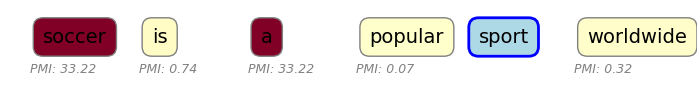

In [4]:
# Your code here. You are more than welcome to build .py file and run with that.
from tools.calculate_pmi import (
    compute_probs, 
    visualize,
)
import numpy as np

words = sentence.lower().split()
anchor = words[anchor_word_idx]
word_indices = [i for i in range(len(words)) if i != anchor_word_idx]
pmi_scores = []
for i, mask_responses in enumerate(all_responses):
    # Compute probabilities
    y = words[word_indices[i]]
    p_x, p_y, p_xy = compute_probs(anchor, y, mask_responses)

    # Calculate PMI score
    pmi_score = np.log2(p_xy / (p_x * p_y))
    pmi_scores.append(pmi_score)

    print(f"p({anchor}) = {p_x}")
    print(f"p({y}) = {p_y}")
    print(f"p({anchor},{y}) = {p_xy}")
    print(f"pmi({anchor},{y}) = {pmi_score}")
    print("----------")

# Visualize the results
visualize(words, anchor_word_idx, pmi_scores, save_path='figures/pmi_sport.png')


## 4. EXERCISE: Try more examples; maybe come up with your own. Report the results.

* Try to come up with more examples and, change the anchor word/number of responses, and observe the results. What does the explanation mean? Do you think it's a nice explanation? Why and why not?
> We have teste different sentence like to investigate the effect of using similar words. Also each sentence have been run with different relevant anchor words to better understand the relevance between words.
* What's the limitation of the current method? When does the method fail to explain?
> There are certain limitations to the current method like how it is reliant on the prompt, similar words in meaning are treated as wrong generations, or how you have to handle edge cases of having the same word multiple times in the same sentence.

## 5. Bonus Exercises
### 5.1 Language pre-processing. 
In this exercise, we only lower the letters and split sentences into words; there's much more to do to pre-process the language. For example, contractions (*I'll*, *She's*, *world's*), suffix and prefix, compound words (*hard-working*). It's called word tokenization in NLP, and there are some Python packages that can do such work for us, e.g. [*TextBlob*](https://textblob.readthedocs.io/en/dev/). 


### 5.2 Better word matching
In the above example of
> Tokyo is the capital of Japan and a popular metropolis in the world.

, GenAI never gives the specific word 'metropolis' when masking it out; instead, sometimes it provides words like 'city', which is not the same word but has a similar meaning. Instead of measuring the exact matching of certain words (i.e. 0 or 1), we can also measure the similarity of two words, e.g. the cosine similarity in word embedding, which ranges from 0 to 1. 